In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_value

import corner

from sp import *

from jaxoplanet.starry.ylm import Ylm
from jaxoplanet.starry.surface import Surface
from jaxoplanet.starry.visualization import show_surface


In [4]:
lmax = 5
r = np.deg2rad(20.0)
c = 0.1
nspots = 10.0
period = 1.0

ncurves = 50
ntimes = 500
ferr = 1e-3

inc = np.pi / 2
obl = 0.0

t = jnp.linspace(0.0, 4.0, ntimes)
theta = 2.0 * jnp.pi * jnp.mod(t / period, 1.0)

MU_TRUE_DEG = 60.0
SIGMA_TRUE_DEG = 5.0

seed = 123

In [5]:
a_true, b_true = map(float, gauss_to_ab(MU_TRUE_DEG, SIGMA_TRUE_DEG))
alpha_true, beta_true = map(float, ab_to_alpha_beta(a_true, b_true))
mu_check, sigma_check = map(float, ab_to_latitude(a_true, b_true))

print("true a,b       =", a_true, b_true)
print("true alpha,beta=", alpha_true, beta_true)
print("recovered mu,sigma =", mu_check, sigma_check)


W1008 14:31:39.452901  676050 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


true a,b       = 0.3125631150885175 0.3557450107475467
true alpha,beta= 22.77426455563385 22.440931222300506
recovered mu,sigma = 60.00000000000071 4.9999999999999485


In [6]:
sp = StarryProcess(alpha_true,beta_true,contrast=c,r=r,nspots=nspots,lmax=lmax)

In [7]:
sp

In [8]:
M = sp.design_matrix(theta=theta,inc=inc,obl=obl,period=period)

In [11]:
mean_true, cov_true = sp.moments()
key = jax.random.PRNGKey(seed)
key_ylm, key_noise = jax.random.split(key)

In [12]:
ylm_samples = sp.sample_ylm(key=key,nsamples=ncurves)
flux = sp.sample_flux(ylm_samples,M)

In [13]:
measurement_noise = ferr * jax.random.normal(key_noise, flux.shape)
f = flux + measurement_noise

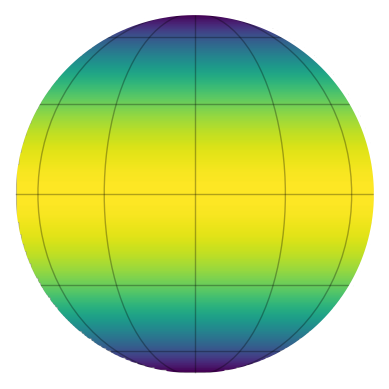

In [14]:
show_surface(mean_true)

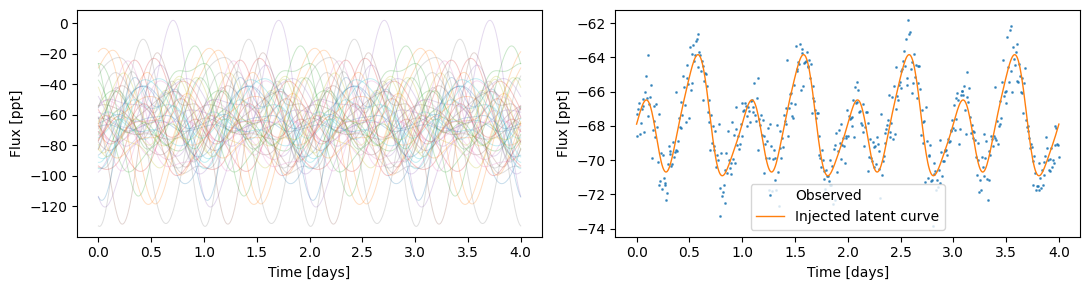

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].plot(t, 1e3 * np.asarray(flux).T, alpha=0.25, lw=0.7)
axes[0].set(xlabel='Time [days]', ylabel='Flux [ppt]')
axes[1].plot(t, 1e3 * np.asarray(f[0]), '.', ms=2, alpha=0.7, label='Observed')
axes[1].plot(t, 1e3 * np.asarray(flux[0]), lw=1, label='Injected latent curve')
axes[1].set(xlabel='Time [days]', ylabel='Flux [ppt]')
axes[1].legend()
plt.tight_layout()
plt.show()

In [18]:
@jax.jit
def log_likelihood_ab(a, b, c=c, r=r, nspots=nspots, lmax=lmax):
    alpha, beta = ab_to_alpha_beta(a, b)
    sp_ll = StarryProcess(alpha, beta, contrast=c, r=r, nspots=nspots, lmax=lmax)
    mean_ylm, cov_ylm = sp_ll.moments()
    mean_flux = M @ mean_ylm

    ncurves_, nt = f.shape
    ny = mean_ylm.shape[0]
    noise_var = ferr**2
    Dinv = 1.0 / noise_var

    # B = I + C M^T D^-1 M
    mt_m = M.T @ M
    B = jnp.eye(ny) + cov_ylm @ (Dinv * mt_m)

    resid = (f - mean_flux[None, :]).T  # (nt, ncurves)
    rhs = cov_ylm @ (M.T @ (Dinv * resid))
    corr = M @ jnp.linalg.solve(B, rhs)

    quad = jnp.sum(resid * (Dinv * resid), axis=0) - jnp.sum((Dinv * resid) * corr, axis=0)

    _, logdet_B = jnp.linalg.slogdet(B)
    logdet = nt * jnp.log(noise_var) + logdet_B
    constant = nt * jnp.log(2.0 * jnp.pi)

    return -0.5 * jnp.sum(quad + logdet + constant)

In [19]:
ll_true = float(log_likelihood_ab(a_true, b_true))
grad_true = jax.grad(log_likelihood_ab, argnums=(0, 1))(a_true, b_true)
print('log likelihood at truth:', ll_true)
print('gradient at truth:', float(grad_true[0]), float(grad_true[1]))

log likelihood at truth: 135690.63703435712
gradient at truth: -410.7055294901665 451.62978677215887


In [20]:
def model():
    a = numpyro.sample('a', dist.Uniform(1e-4, 1.0))
    b = numpyro.sample('b', dist.Uniform(1e-4, 1.0))
    ll = log_likelihood_ab(a, b)
    numpyro.factor('loglik_factor', ll)
    numpyro.deterministic('log_likelihood', ll)

kernel = NUTS(model, target_accept_prob=0.8, dense_mass=False)
mcmc = MCMC(kernel, num_warmup=200, num_samples=1000, num_chains=1, progress_bar=True)

mcmc.run(jax.random.PRNGKey(seed + 1))
mcmc.print_summary()

sample: 100%|██████████| 1200/1200 [04:00<00:00,  5.00it/s, 19 steps of size 4.14e-02. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a      0.31      0.02      0.31      0.28      0.34    184.40      1.02
         b      0.36      0.02      0.36      0.33      0.39    184.68      1.02

Number of divergences: 0


In [21]:
samples = mcmc.get_samples()

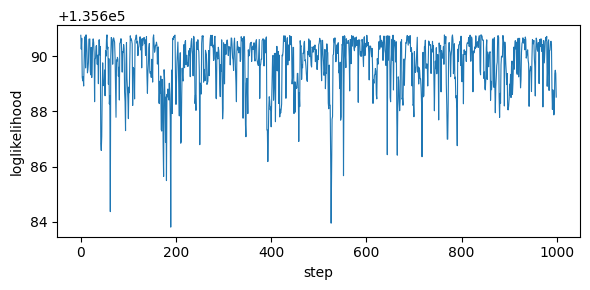

In [22]:
ll_trace = np.asarray(samples['log_likelihood'])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(ll_trace, lw=0.8)
ax.set(xlabel='step', ylabel='loglikelihood')
plt.tight_layout()
plt.show()

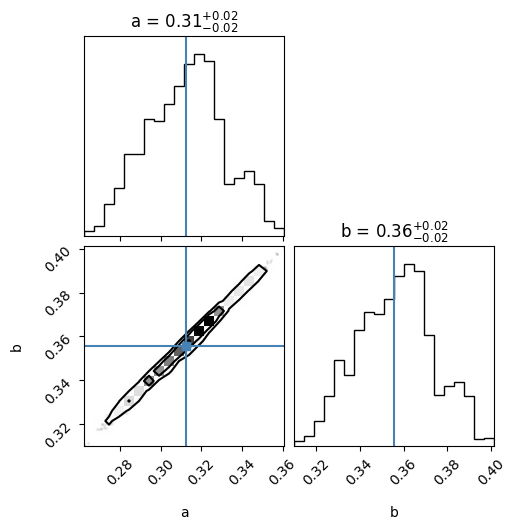

In [23]:
import corner

arr_ab = np.column_stack([np.asarray(samples['a']), np.asarray(samples['b'])])
fig = corner.corner(
    arr_ab,
    labels=['a', 'b'],
    truths=[a_true, b_true],
    show_titles=True,
)
plt.show()

In [24]:
mu_sigma_post = jax.vmap(ab_to_latitude)(samples['a'], samples['b'])
mu_post = np.asarray(mu_sigma_post[:, 0])
sigma_post = np.asarray(mu_sigma_post[:, 1])

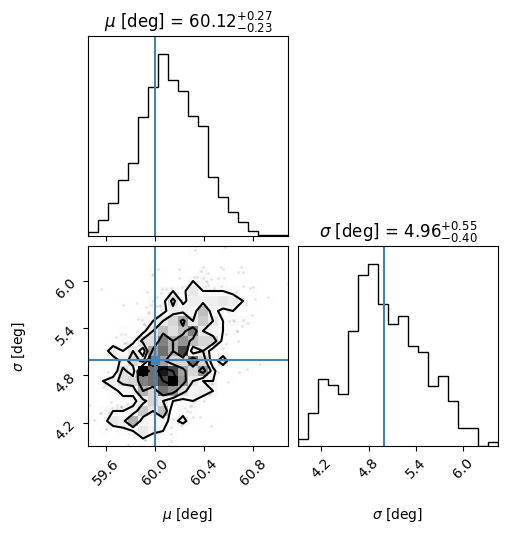

In [25]:
fig = corner.corner(
    np.column_stack([mu_post, sigma_post]),
    labels=[r'$\mu$ [deg]', r'$\sigma$ [deg]'],
    truths=[MU_TRUE_DEG, SIGMA_TRUE_DEG],
    show_titles=True,
)
plt.show()

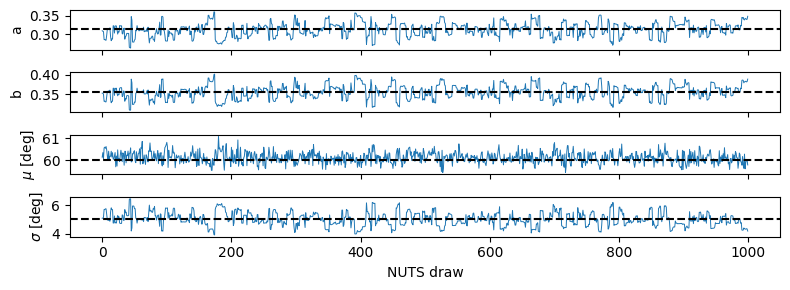

In [26]:
a_trace = np.asarray(samples["a"])
b_trace = np.asarray(samples["b"])

mu_sigma_trace = np.asarray(jax.vmap(ab_to_latitude)(samples["a"],samples["b"]))

mu_trace = mu_sigma_trace[:, 0]
sigma_trace = mu_sigma_trace[:, 1]

fig, axes = plt.subplots(4,1,figsize=(8, 3),sharex=True,)

axes[0].plot(a_trace, lw=0.7)
axes[0].axhline(a_true, color="k", ls="--")
axes[0].set_ylabel("a")

axes[1].plot(b_trace, lw=0.7)
axes[1].axhline(b_true, color="k", ls="--")
axes[1].set_ylabel("b")

axes[2].plot(mu_trace, lw=0.7)
axes[2].axhline(MU_TRUE_DEG, color="k", ls="--")
axes[2].set_ylabel(r"$\mu$ [deg]")

axes[3].plot(sigma_trace, lw=0.7)
axes[3].axhline(SIGMA_TRUE_DEG, color="k", ls="--")
axes[3].set_ylabel(r"$\sigma$ [deg]")
axes[3].set_xlabel("NUTS draw")

plt.tight_layout()
plt.show()

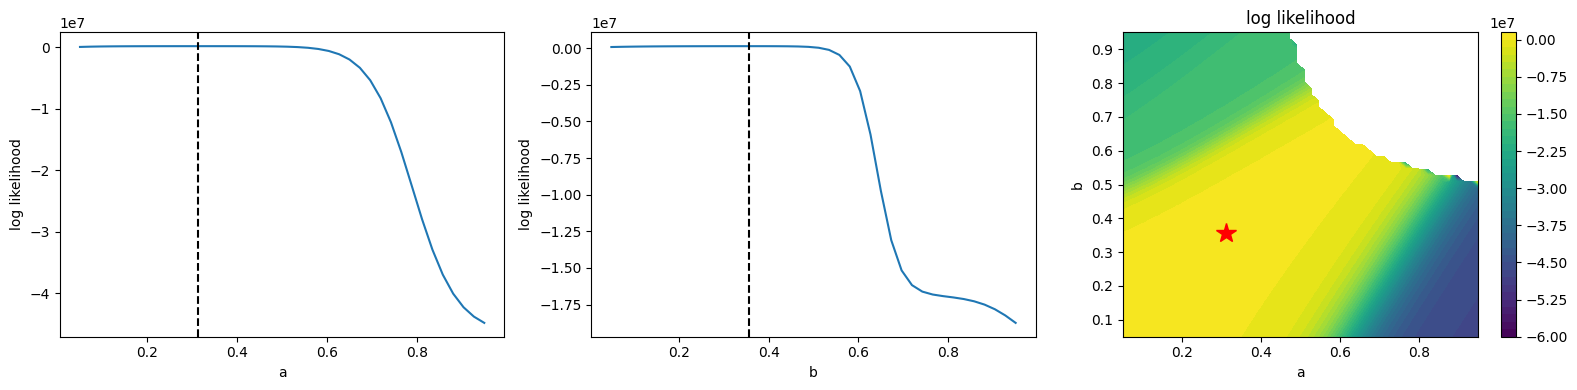

peak of a-slice at a = 0.3038461538461538  (truth 0.3125631150885175 )
peak of b-slice at b = 0.35  (truth 0.3557450107475467 )


In [27]:
grid = np.linspace(0.05, 0.95, 40)

ll_a = np.array([log_likelihood_ab(x, b_true) for x in grid])

ll_b = np.array([log_likelihood_ab(a_true, x) for x in grid])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].plot(grid, ll_a)
ax[0].axvline(a_true, color="k", ls="--")
ax[0].set(xlabel="a",ylabel="log likelihood")

ax[1].plot(grid, ll_b)
ax[1].axvline(b_true, color="k", ls="--")
ax[1].set(xlabel="b",ylabel="log likelihood")

g = np.linspace(0.05, 0.95, 50)
Z = np.array([[log_likelihood_ab(a, b) for a in g] for b in g])

im = ax[2].contourf(g,g,Z,levels=40)
ax[2].plot(a_true,b_true,"r*",ms=15)
ax[2].set(xlabel="a",ylabel="b",title="log likelihood")

plt.colorbar(im, ax=ax[2])
plt.tight_layout()
plt.show()

print("peak of a-slice at a =",grid[np.nanargmax(ll_a)]," (truth",a_true,")")
print("peak of b-slice at b =",grid[np.nanargmax(ll_b)]," (truth",b_true,")")

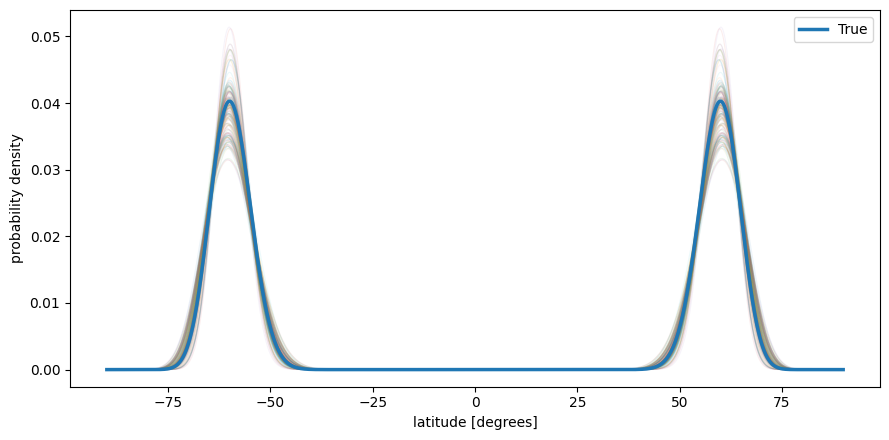

In [28]:
from scipy.stats import beta as beta_dist

phi = np.linspace(-90, 90, 1000)
phi_rad = np.deg2rad(phi)
x = np.cos(phi_rad)

alpha_post, beta_post = jax.vmap(ab_to_alpha_beta)(samples["a"], samples["b"])
alpha_post = np.asarray(alpha_post)
beta_post = np.asarray(beta_post)

alpha_true, beta_true = map(float, ab_to_alpha_beta(a_true, b_true))

jac = 0.5 * np.abs(np.sin(phi_rad)) * np.pi / 180.0
pdf_true = jac * beta_dist.pdf(x, alpha_true, beta_true)

fig, ax = plt.subplots(figsize=(9, 4.5))

nsamples_plot = min(200, len(alpha_post))
for alpha, beta in zip(alpha_post[:nsamples_plot], beta_post[:nsamples_plot]):
    pdf = jac * beta_dist.pdf(x, alpha, beta)
    ax.plot(phi, pdf, alpha=0.08, lw=0.8)

ax.plot(phi, pdf_true, lw=2.5, label="True")

ax.set_xlabel("latitude [degrees]")
ax.set_ylabel("probability density")
ax.legend()

plt.tight_layout()
plt.show()

In [29]:
flux_cond = sp.sample_conditional_flux(mean_ylm=mean_true,cov_ylm=cov_true,f=f,M=M,ferr=ferr,key=key,nsamples=500)

In [30]:
flux_cond.shape

(50, 500, 500)

In [31]:
i = 36

f_obs = f[i]
flux_cond_i = flux_cond[i]

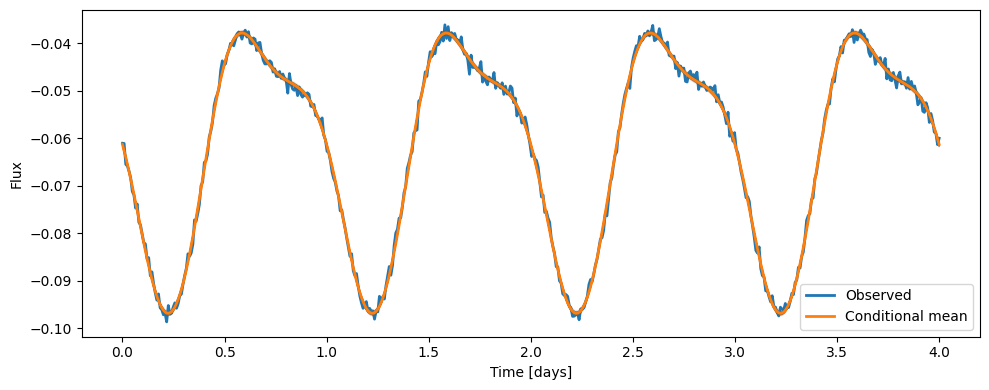

In [32]:
fig,ax = plt.subplots(figsize=(10,4))

ax.plot(t,f_obs,lw=2,label="Observed")
ax.plot(t,flux_cond_i.T,alpha=0.03,lw=0.7)
ax.plot(t,jnp.mean(flux_cond_i,axis=0),lw=2,label="Conditional mean")

ax.set_xlabel("Time [days]")
ax.set_ylabel("Flux")
ax.legend()

plt.tight_layout()
plt.show()